In [5]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
!pip install -q gdown
import gdown

url1 = "https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
url2 = "https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

gdown.download(url1, "his_data.csv", quiet=False)
gdown.download(url2, "fear_greed.csv", quiet=False)



his_data = pd.read_csv("his_data.csv")
fear_greed = pd.read_csv("fear_greed.csv")

Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/his_data.csv
100%|██████████| 47.5M/47.5M [00:01<00:00, 46.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/fear_greed.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 3.10MB/s]


In [14]:
his_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
his_data.shape

(211224, 16)

In [16]:
his_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [17]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [18]:
fear_greed.shape

(2644, 4)

In [19]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [20]:
#Formatting data type pf "Timestamp IST", "date" columns from both datasets to enable merging them.
his_data['Timestamp IST'] = pd.to_datetime(
    his_data['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)


In [21]:
his_data['date'] = his_data['Timestamp IST'].dt.date

In [26]:
his_data['date'].head()

,date
0,2024-12-02
1,2024-12-02
2,2024-12-02
3,2024-12-02
4,2024-12-02


In [24]:
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date



In [27]:
fear_greed['date'].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [28]:
#MErging the two data sets
merged_df = pd.merge(
    his_data,
    fear_greed,
    on='date',
    how='left'
)

In [29]:
merged_df.shape

(211224, 20)

In [31]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [32]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [34]:
#Checking for null values and dropping them
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [35]:
merged_df = merged_df[merged_df['classification'].notna()]

In [36]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [38]:
#Dropping columns which are not useful for EDA
drop_cols = [
    'Timestamp IST',
    'Transaction Hash',
    'Order ID',
    'Trade ID',
    'Timestamp',
    'Crossed'
]



In [39]:
merged_df.drop(columns=drop_cols, inplace=True)

KeyError: "['Timestamp IST', 'Transaction Hash', 'Order ID', 'Trade ID', 'Timestamp', 'Crossed'] not found in axis"

In [40]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211218 entries, 0 to 211223
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Account          211218 non-null  object 
 1   Coin             211218 non-null  object 
 2   Execution Price  211218 non-null  float64
 3   Size Tokens      211218 non-null  float64
 4   Size USD         211218 non-null  float64
 5   Side             211218 non-null  object 
 6   Start Position   211218 non-null  float64
 7   Direction        211218 non-null  object 
 8   Closed PnL       211218 non-null  float64
 9   Fee              211218 non-null  float64
 10  date             211218 non-null  object 
 11  timestamp        211218 non-null  float64
 12  value            211218 non-null  float64
 13  classification   211218 non-null  object 
dtypes: float64(8), object(6)
memory usage: 24.2+ MB


In [41]:
#Sentiment distribution
merged_df['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [42]:
import matplotlib.pyplot as plt

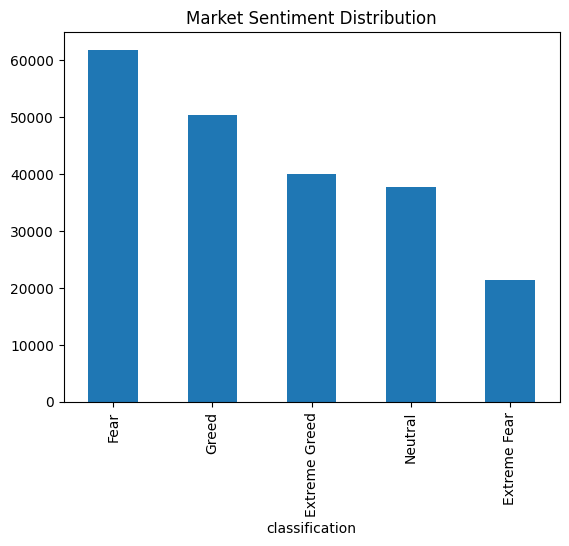

In [43]:
merged_df['classification'].value_counts().plot(kind='bar')
plt.title("Market Sentiment Distribution")
plt.show()

In [44]:
#Buy vs Sell distribution
merged_df['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102690


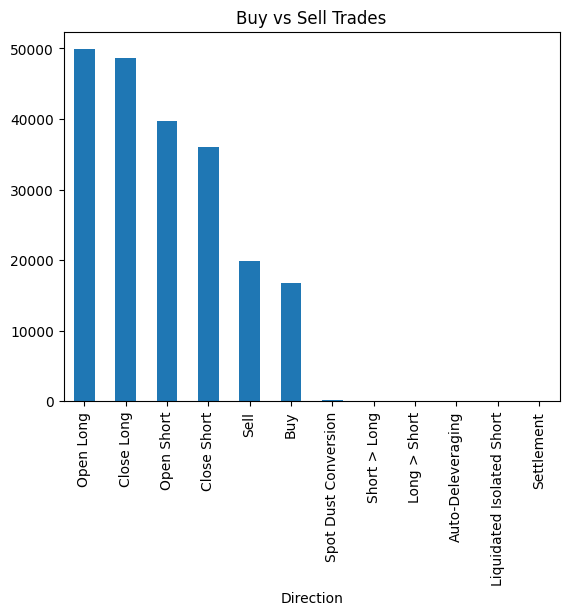

In [45]:
merged_df['Direction'].value_counts().plot(kind='bar')
plt.title("Buy vs Sell Trades")
plt.show()

In [46]:
#Average PnL by sentiment
merged_df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


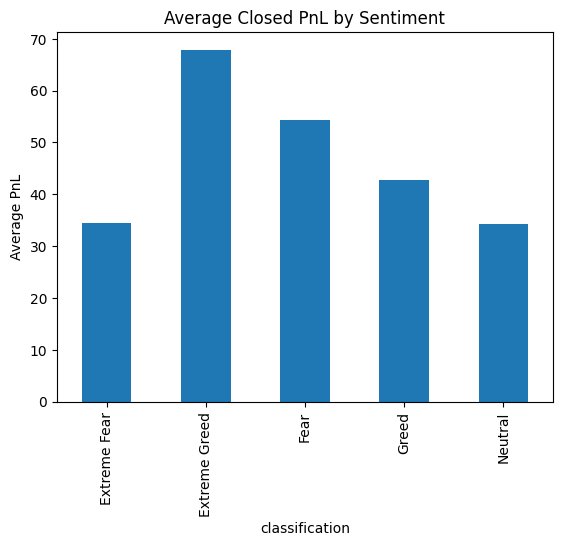

In [47]:
merged_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average PnL")
plt.show()


In [48]:
#Number of Buy/Sell trades under each sentiment
pd.crosstab(
    merged_df['classification'],
    merged_df['Direction']
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


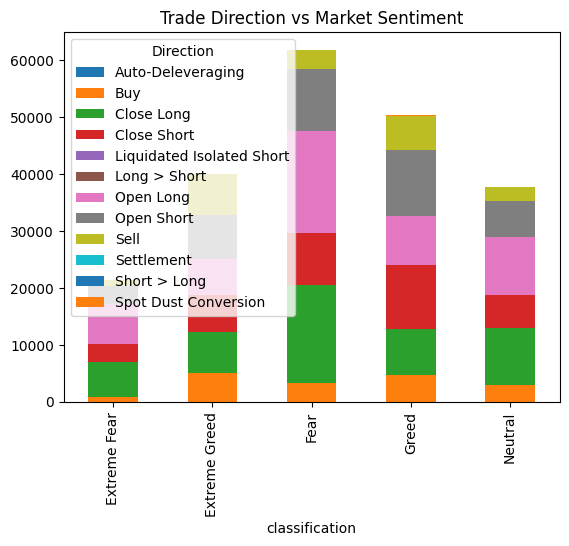

In [49]:
pd.crosstab(
    merged_df['classification'],
    merged_df['Direction']
).plot(kind='bar', stacked=True)
plt.title("Trade Direction vs Market Sentiment")
plt.show()

In [50]:
#Trade size vs sentiment
merged_df.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


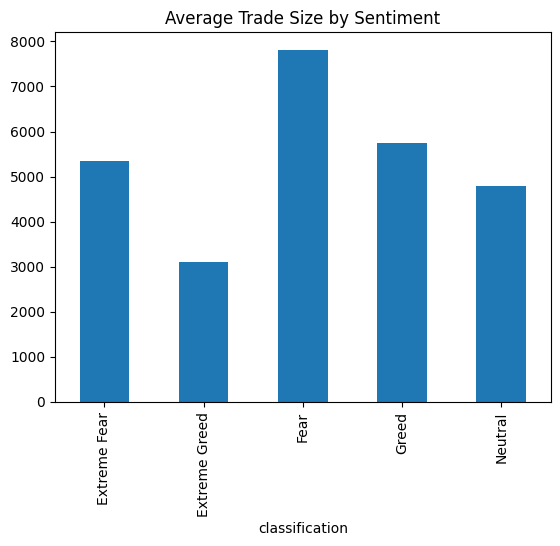

In [51]:

merged_df.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.show()

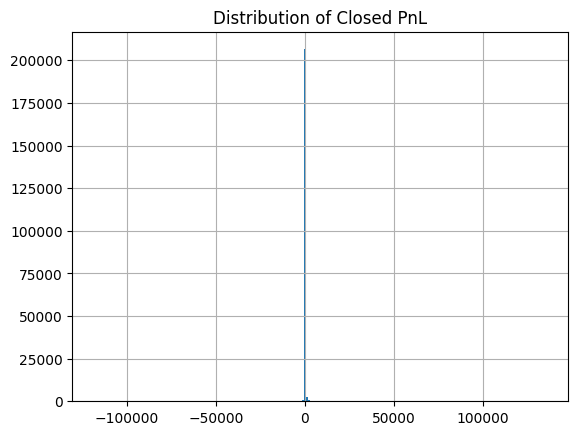

In [53]:
#Distribution of PnL
merged_df['Closed PnL'].hist(bins=50)
plt.title("Distribution of Closed PnL")
plt.show()

In [54]:
#Top profitable traders
merged_df.groupby('Account')['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05


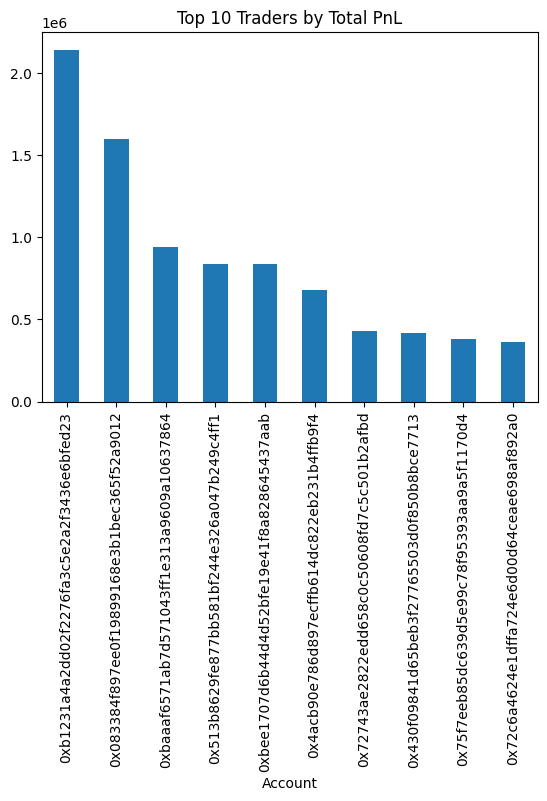

In [55]:
merged_df.groupby('Account')['Closed PnL'].sum().sort_values(
    ascending=False
).head(10).plot(kind='bar')
plt.title("Top 10 Traders by Total PnL")
plt.show()

In [56]:
#Correlation analysis
numeric_cols = [
    'Execution Price',
    'Size USD',
    'Closed PnL',
    'Fee',
    'value'
]

merged_df[numeric_cols].corr()

,Execution Price,Size USD,Closed PnL,Fee,value
Execution Price,1.000000,0.189859,-0.006429,0.225266,-0.027558
Size USD,0.189859,1.000000,0.123645,0.745940,-0.029843
Closed PnL,-0.006429,0.123645,1.000000,0.084094,0.008121
Fee,0.225266,0.745940,0.084094,1.000000,-0.026877
value,-0.027558,-0.029843,0.008121,-0.026877,1.000000


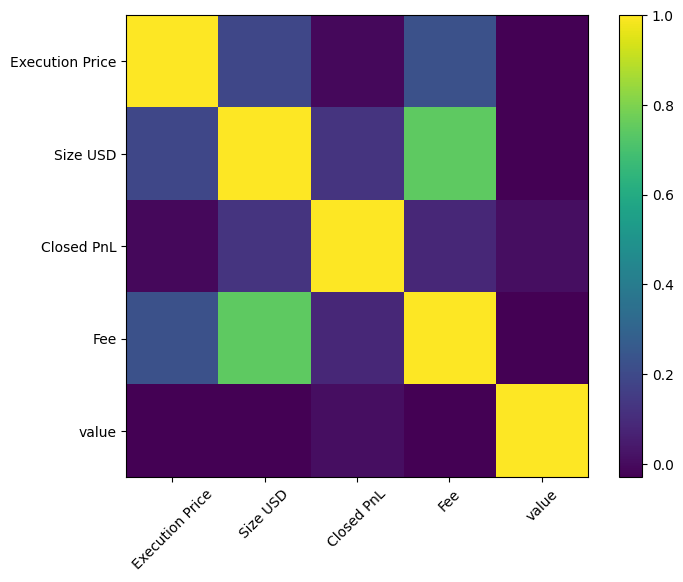

In [57]:
corr = merged_df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

In [60]:
#To Check trader profitability change with sentiment
merged_df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [61]:
#Checking Does trader behavior (Buy/Sell) change with sentiment
pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


<Axes: xlabel='classification'>

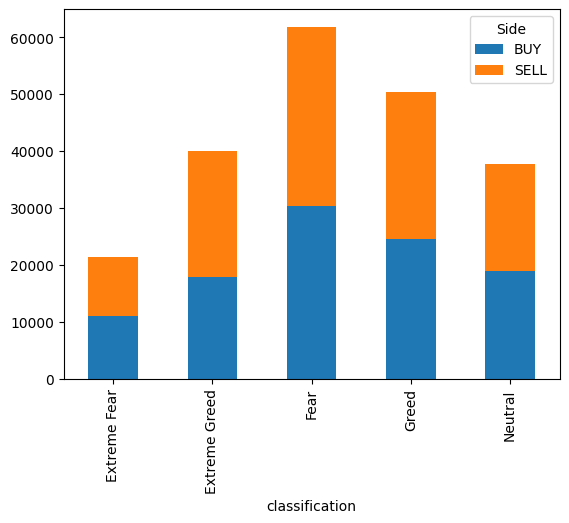

In [62]:
#Visualize Buy/Sell vs Sentiment
pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
).plot(kind='bar', stacked=True)

In [63]:
# Top 10% traders vs Bottom 10% traders

trader_pnl = (
    merged_df.groupby('Account')['Closed PnL']
    .sum()
    .reset_index()
)

trader_pnl.head()

,Account,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05


In [64]:
top_cutoff = trader_pnl['Closed PnL'].quantile(0.90)
bottom_cutoff = trader_pnl['Closed PnL'].quantile(0.10)

print(top_cutoff)
print(bottom_cutoff)

839988.3550021
14501.271707099997


In [65]:
top_traders = trader_pnl[
    trader_pnl['Closed PnL'] >= top_cutoff
]

bottom_traders = trader_pnl[
    trader_pnl['Closed PnL'] <= bottom_cutoff
]

In [66]:
# Checking average trade size of top and bottom traders
top_data = merged_df[
    merged_df['Account'].isin(top_traders['Account'])
]

bottom_data = merged_df[
    merged_df['Account'].isin(bottom_traders['Account'])
]

print("Top Traders Avg Trade Size")
print(top_data['Size USD'].mean())

print("Bottom Traders Avg Trade Size")
print(bottom_data['Size USD'].mean())

Top Traders Avg Trade Size
11680.75041459051
Bottom Traders Avg Trade Size
4886.8796605275475


In [67]:
#Clustering traders based on behavior

trader_features = merged_df.groupby(
    'Account'
).agg({

    'Closed PnL':'sum',
    'Size USD':'mean',
    'value':'mean',
    'Account':'count'

})

trader_features.columns = [
    'TotalPnL',
    'AvgTradeSize',
    'AvgSentiment',
    'TradeCount'
]

trader_features.head()

,TotalPnL,AvgTradeSize,AvgSentiment,TradeCount
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,53.754060,3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,52.213462,7280
0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,39.409556,3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,68.774322,13311
0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,61.667490,3239


In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(trader_features)

In [69]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_features['Cluster'] = kmeans.fit_predict(scaled)

In [70]:
trader_features.groupby(
    'Cluster'
).mean()

,TotalPnL,AvgTradeSize,AvgSentiment,TradeCount
Cluster,,,,
0,551074.217759,11317.180312,41.582805,6344.538462
1,131855.944478,1996.922442,65.567563,7707.333333
2,190381.861813,2710.481652,51.088026,5937.300000


##Exploratory Data Analysis (EDA) Summary
#1. Data Preparation

Merged the Historical Trader Data with the Bitcoin Fear & Greed Index using the transaction date.

Removed a small number of unmatched records (6 rows) that did not have corresponding sentiment data.

Performed basic data cleaning and verified that the merged dataset contained no significant missing values.

#2. Market Sentiment Distribution
Fear was the most frequently observed market condition, followed by Greed.

Extreme Fear had the lowest number of trading records, indicating that highly pessimistic market conditions occurred less frequently during the observed period.

#3. Trader Profitability vs. Market Sentiment

Average Closed PnL by sentiment:

| Sentiment	| Avg. Closed PnL |

| Extreme Greed |67.89|

| Fear	| 54.29 |

| Greed |	42.74 |

| Extreme Fear |	34.54 |

| Neutral	| 34.31 |

Key Observation:

Traders achieved the highest average profits during Extreme Greed periods.

Contrary to common expectations, the dataset suggests that bullish market conditions were generally more profitable than fearful markets.

#4. Trading Behavior under Different Market Conditions

Both BUY and SELL activities increased during Fear and Greed periods.

SELL trades consistently outnumbered BUY trades across all sentiment categories.

Fear periods showed the highest overall trading activity, indicating increased market participation during uncertain conditions.

#5. Trade Size Analysis

The average trade size was highest during Fear periods (approximately $7.8K), followed by Greed.

Extreme Greed showed comparatively smaller average trade sizes.

This suggests that traders may commit larger capital during market downturns while realizing greater profits during strong bullish trends.

#6. Top vs. Bottom Performing Traders

Top 10% traders had an average trade size of approximately 11,681 USD.

Bottom 10% traders had an average trade size of approximately 4,887 USD.


**Insight**:

More successful traders generally executed larger trades, indicating better capital allocation or higher confidence in their trading strategies.

#7. Correlation Analysis

A strong positive relationship was observed between Trade Size and Trading Fee, which is expected as fees are volume-dependent.

The numeric Fear & Greed score showed very weak linear correlation with Closed PnL, suggesting that market sentiment alone is not sufficient to predict trader profitability.

#8. Trader Segmentation (Clustering)

Three distinct trader clusters emerged:

**Cluster 0**: High-volume, high-profit traders with the largest average trade size.

**Cluster 1**: Low-volume traders with relatively lower profitability despite higher trading frequency.

**Cluster 2**: Medium-volume traders with moderate profitability.

This indicates that trading behavior varies significantly across different trader groups.

##Overall Conclusion

The analysis suggests that market sentiment influences both trader behavior and performance. While trading activity peaks during Fear periods, the highest average profitability is observed during Extreme Greed. Additionally, larger trade sizes are associated with better-performing traders, and trader segmentation reveals distinct behavioral patterns that could be useful for developing more effective trading strategies.